# Tarea 1: SGD

No tenemos (hasta donde tenemos entendido) un número de equipo, pero estamos conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez


Las instrucciones para reproducir esta tarea por se encuentran en el [siguiente repositorio](https://github.com/MelodiousZero/tareas_modulo_7_diplomado) particularmente la parte del `README.md` que habla de los ambientes virtuales y el `requirements.txt`. 

## SGD y alguna de sus variantes
### Descripción del problema

Vamos a implementar SGD y su variante AdaGrad para la pérdida cross entropy y usarlo en un problema de regresión logística con el siguiente dataset: Fashion MNIST,

### Metodología

Usaremos dos clases `LogsisticRegressionSGD` y `LogisticRegressionAdaGrad` los cuales se encuentran en `clases.py`. Para dejar el notebook limpio y sin mucho código. En ellas usaremos cross entropy loss.

### Resultados

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import warnings


Cargamos el conjunto de datos.


In [34]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

Y ahora dividimos en train y test. Además, creamos nombres para las clases (tipos de ropa)

In [35]:
X_train = train_dataset.data.numpy()  
y_train = train_dataset.targets.numpy()  

X_test = test_dataset.data.numpy()  
y_test = test_dataset.targets.numpy()  


X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0



class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


Y las imagenes se ven así:

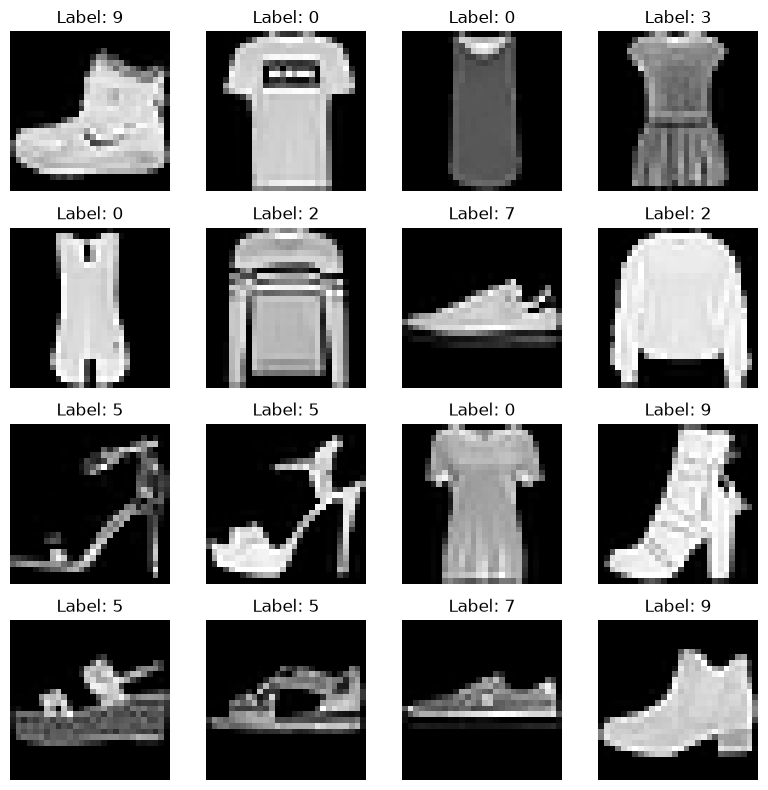

In [36]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        image, label = train_dataset[i * 4 + j]  
        image_numpy = image.numpy().squeeze()    
        axs[i, j].imshow(image_numpy, cmap='gray')  
        axs[i, j].axis('off')  
        axs[i, j].set_title(f"Label: {label}") 

plt.tight_layout()  
plt.show()  

Hacemos preprocesamiento de datos, lo cual incluye escalamiento:

In [37]:

X_train_subset, X_val, y_train_subset, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train subset: {X_train_subset.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_subset)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_val_bias = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"\nCon bias - Train: {X_train_bias.shape}")
print(f"Con bias - Validation: {X_val_bias.shape}")
print(f"Con bias - Test: {X_test_bias.shape}")






Train subset: (54000, 784)
Validation: (6000, 784)
Test: (10000, 784)

Con bias - Train: (54000, 785)
Con bias - Validation: (6000, 785)
Con bias - Test: (10000, 785)


Y ahor así, entrenamos los modelos:

In [38]:

from clases import LogsisticRegressionSGD,LogisticRegressionAdaGrad

# Entrenar SGD
sgd_model = LogsisticRegressionSGD(learning_rate=0.01, n_iterations=500)
sgd_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)

# Entrenar AdaGrad
adagrad_model = LogisticRegressionAdaGrad(learning_rate=0.1, n_iterations=500)
adagrad_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)





Entrenando SGD...


100%|██████████| 500/500 [01:17<00:00,  6.46it/s]



Entrenando AdaGrad...


100%|██████████| 500/500 [01:17<00:00,  6.49it/s]


La evaluación de cada uno es la siguiente:

In [39]:


# Predecir con SGD
y_pred_sgd = sgd_model.predict(X_test_bias)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print(f"\nSGD - Accuracy en test: {acc_sgd:.4f}")

# Predecir con AdaGrad
y_pred_adagrad = adagrad_model.predict(X_test_bias)
acc_adagrad = accuracy_score(y_test, y_pred_adagrad)
print(f"AdaGrad - Accuracy en test: {acc_adagrad:.4f}")



SGD - Accuracy en test: 0.8173
AdaGrad - Accuracy en test: 0.8357


Por último, una visualización de datos:


GENERANDO VISUALIZACIONES


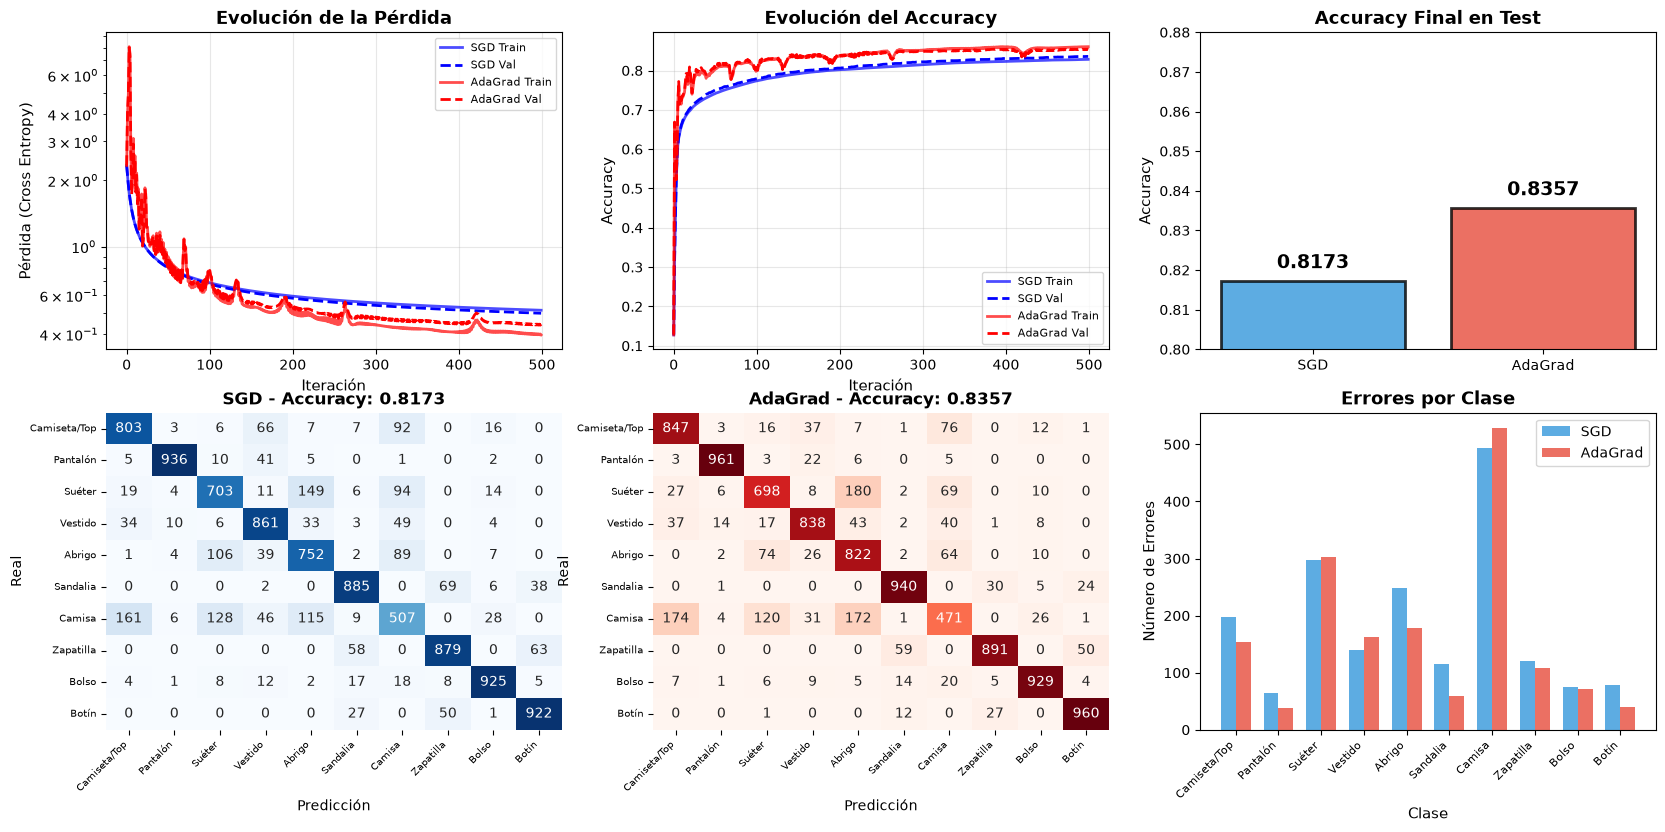

In [ ]:


# Configurar figura principal
fig = plt.figure(figsize=(20, 14))

# 6.1 Evolución de la pérdida (Train + Val)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(sgd_model.loss_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(sgd_model.val_loss_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax1.plot(adagrad_model.loss_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax1.plot(adagrad_model.val_loss_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax1.set_xlabel('Iteración', fontsize=11)
ax1.set_ylabel('Pérdida (Cross Entropy)', fontsize=11)
ax1.set_title('Evolución de la Pérdida', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 6.2 Evolución del accuracy (Train + Val)
ax2 = plt.subplot(3, 3, 2)
ax2.plot(sgd_model.accuracy_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax2.plot(sgd_model.val_accuracy_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax2.plot(adagrad_model.accuracy_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax2.plot(adagrad_model.val_accuracy_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Evolución del Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 6.3 Comparación de accuracy final
ax3 = plt.subplot(3, 3, 3)
models_names = ['SGD', 'AdaGrad']
accuracies = [acc_sgd, acc_adagrad]
colors = ['#3498db', '#e74c3c']
bars = ax3.bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('Accuracy Final en Test', fontsize=13, fontweight='bold')
ax3.set_ylim([0.80, 0.88])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

# 6.4 Matriz de confusión - SGD
ax4 = plt.subplot(3, 3, 4)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax4.set_title(f'SGD - Accuracy: {acc_sgd:.4f}', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicción')
ax4.set_ylabel('Real')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax4.get_yticklabels(), rotation=0, fontsize=7)

# 6.5 Matriz de confusión - AdaGrad
ax5 = plt.subplot(3, 3, 5)
cm_adagrad = confusion_matrix(y_test, y_pred_adagrad)
sns.heatmap(cm_adagrad, annot=True, fmt='d', cmap='Reds', ax=ax5,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax5.set_title(f'AdaGrad - Accuracy: {acc_adagrad:.4f}', fontsize=12, fontweight='bold')
ax5.set_xlabel('Predicción')
ax5.set_ylabel('Real')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax5.get_yticklabels(), rotation=0, fontsize=7)

# 6.6 Errores por clase
ax6 = plt.subplot(3, 3, 6)
errors_sgd = np.sum(cm_sgd, axis=1) - np.diag(cm_sgd)
errors_adagrad = np.sum(cm_adagrad, axis=1) - np.diag(cm_adagrad)
x_pos = np.arange(len(class_names))
width = 0.35
ax6.bar(x_pos - width/2, errors_sgd, width, label='SGD', color='#3498db', alpha=0.8)
ax6.bar(x_pos + width/2, errors_adagrad, width, label='AdaGrad', color='#e74c3c', alpha=0.8)
ax6.set_xlabel('Clase', fontsize=11)
ax6.set_ylabel('Número de Errores', fontsize=11)
ax6.set_title('Errores por Clase', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax6.legend()


### Conclusiones

Adagrad es mejor, porque (...)